<center><h1>Kalawadia_Krish_HW2</h1></center>
<br>
<br>

Name: Krish Kalawadia
<br>
Github Username: 
<br>
USC ID: 4532974788

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Get the Cycle Power Plant Data Set

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
combined_cycle_power_plant = fetch_ucirepo(id=294) 
  
# data (as pandas dataframes) 
X = combined_cycle_power_plant.data.features 
y = combined_cycle_power_plant.data.targets 

my_dataframe = pd.concat([X,y], axis = 1)
print(y)
print(X)
print(my_dataframe)


          PE
0     463.26
1     444.37
2     488.56
3     446.48
4     473.90
...      ...
9563  460.03
9564  469.62
9565  429.57
9566  435.74
9567  453.28

[9568 rows x 1 columns]
         AT      V       AP     RH
0     14.96  41.76  1024.07  73.17
1     25.18  62.96  1020.04  59.08
2      5.11  39.40  1012.16  92.14
3     20.86  57.32  1010.24  76.64
4     10.82  37.50  1009.23  96.62
...     ...    ...      ...    ...
9563  16.65  49.69  1014.01  91.00
9564  13.19  39.18  1023.67  66.78
9565  31.32  74.33  1012.92  36.48
9566  24.48  69.45  1013.86  62.39
9567  21.60  62.52  1017.23  67.87

[9568 rows x 4 columns]
         AT      V       AP     RH      PE
0     14.96  41.76  1024.07  73.17  463.26
1     25.18  62.96  1020.04  59.08  444.37
2      5.11  39.40  1012.16  92.14  488.56
3     20.86  57.32  1010.24  76.64  446.48
4     10.82  37.50  1009.23  96.62  473.90
...     ...    ...      ...    ...     ...
9563  16.65  49.69  1014.01  91.00  460.03
9564  13.19  39.18  1023.67  6

### (b) Exploring the data

#### i. rows and columns

In [3]:
#Code for printing out the number of rows in this dataset
print("Number of rows in this dataset:",len(my_dataframe))

#Code for printing out the number of columns in this dataset
print("Number of columns in this dataset:", len(my_dataframe.columns))

Number of rows in this dataset: 9568
Number of columns in this dataset: 5


#### ii. pairwise scatterplots of all the varianbles

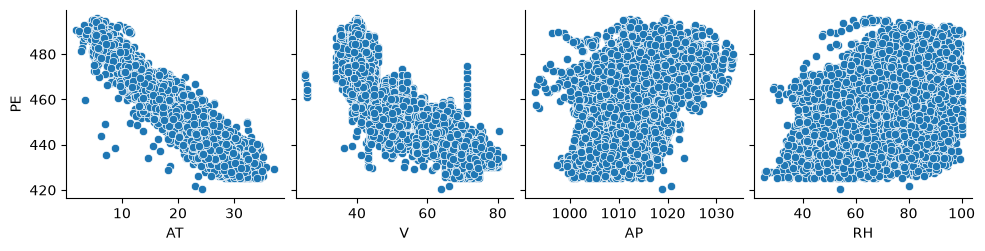

In [4]:
#creating the pairplot of all independent variables in relation to the dependent variable
my_features = ['AT','V','AP','RH']
my_target = 'PE'

sns.pairplot(my_dataframe, x_vars = my_features, y_vars = my_target)
plt.show()


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

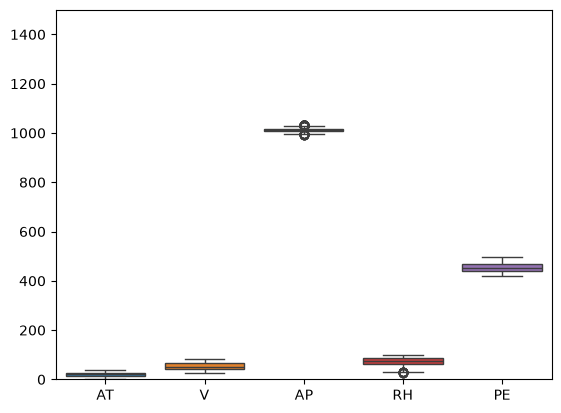

In [5]:
#Implementing a boxplot to be able to figure out the mean,median, range, 1st and 3rd quartiles, and INR
sns.boxplot(data = my_dataframe[['AT','V','AP','RH','PE']])
plt.ylim(0,1500)
plt.show()

In [6]:
#Printing the mean, median, 1st Quant, 3rd Quant, IQR for each variable into a table
my_cols = ['AT','V','AP','RH','PE']

#Creating the table
my_summaryTable = pd.DataFrame({
    'Mean' : my_dataframe[my_cols].mean(),
    'Median' : my_dataframe[my_cols].median(),
    '1st Quartile' : my_dataframe[my_cols].quantile(0.25),
    '3rd Quartile' : my_dataframe[my_cols].quantile(0.75),
    'IQR' : my_dataframe[my_cols].quantile(0.75) - my_dataframe[my_cols].quantile(0.25) })


print(my_summaryTable)

           Mean    Median  1st Quartile  3rd Quartile      IQR
AT    19.651231    20.345       13.5100         25.72  12.2100
V     54.305804    52.080       41.7400         66.54  24.8000
AP  1013.259078  1012.940     1009.1000       1017.26   8.1600
RH    73.308978    74.975       63.3275         84.83  21.5025
PE   454.365009   451.550      439.7500        468.43  28.6800


### (c) Simple Linear Regression

In [7]:
import statsmodels.api as sm

my_predictors = ['AT','V','AP','RH']
my_target = 'PE'

for p in my_predictors:
    X = sm.add_constant(my_dataframe[p])
    y = my_dataframe[my_target]

    my_simple_model = sm.OLS(y,X).fit()

    print('The Predictor:',p)
    print('The Coefficient: ',my_simple_model.params[p])
    print(f'The P-Value:{my_simple_model.pvalues[p]:.100f}')
    print('The R-Squared Value:',my_simple_model.rsquared)
    


The Predictor: AT
The Coefficient:  -2.1713199585177962
The P-Value:0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
The R-Squared Value: 0.8989475964148236
The Predictor: V
The Coefficient:  -1.168135126555711
The P-Value:0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
The R-Squared Value: 0.7565177870683979
The Predictor: AP
The Coefficient:  1.4898716733991122
The P-Value:0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
The R-Squared Value: 0.2687686564110676
The Predictor: RH
The Coefficient:  0.45565010226298
The P-Value:0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
The R-Squared Value: 0.151939440231176


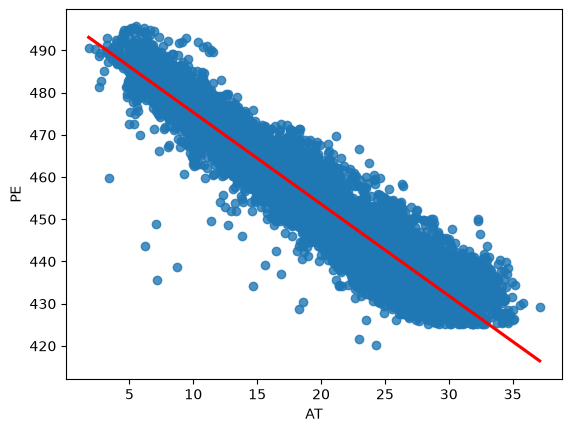

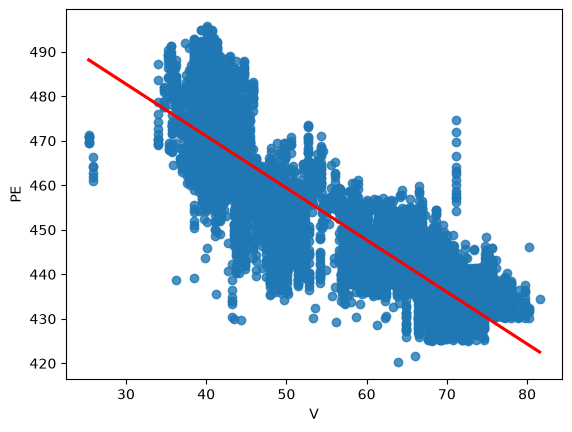

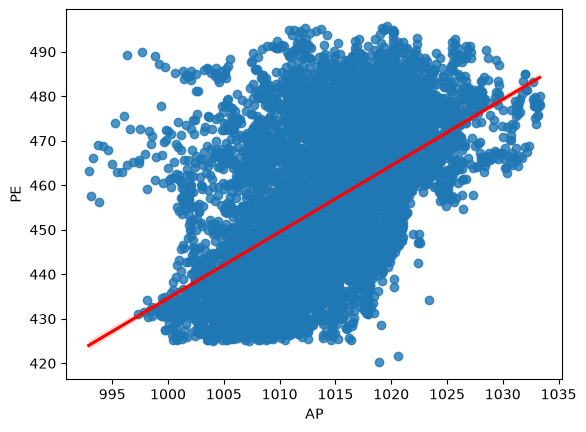

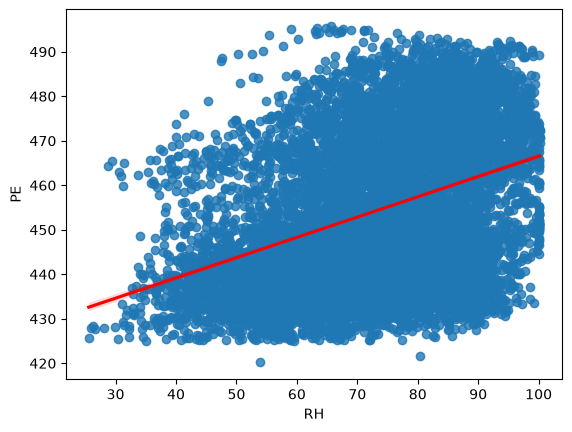

In [8]:
#PLotting the predictors in relation to PE
for p in my_predictors:
    sns.regplot(x = my_dataframe[p],y = my_dataframe[my_target], line_kws = {'color' : 'red'})
    plt.show()

In [9]:
#Finding the outliers that may be visible from some of the plots
for p in my_predictors:
    quartile_1 = my_dataframe[p].quantile(0.25)
    quartile_3 = my_dataframe[p].quantile(0.75)

    my_IQR = quartile_3 - quartile_1
    lower_bound = quartile_1 - 1.5 * my_IQR
    upper_bound = quartile_3 + 1.5 * my_IQR

    my_outliers = my_dataframe[(my_dataframe[p] < lower_bound) | (my_dataframe[p] > upper_bound)]
    print(f"{p} : {len(my_outliers)} outliers found")
    

AT : 0 outliers found
V : 0 outliers found
AP : 88 outliers found
RH : 12 outliers found


### (d) Multiple Regression

In [10]:
#Implementing a multiple linear regression model using all the predictors to predict PE and see if we can reject the NULL
multiple_reg_X = my_dataframe[my_predictors]
y = my_dataframe[my_target]

multiple_reg_x = sm.add_constant(multiple_reg_X)

my_multiple_model = sm.OLS(y,multiple_reg_X).fit()

print(my_multiple_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                     PE   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.939e+07
Date:                Thu, 24 Sep 2026   Prob (F-statistic):                        0.00
Time:                        21:28:22   Log-Likelihood:                         -29068.
No. Observations:                9568   AIC:                                  5.814e+04
Df Residuals:                    9564   BIC:                                  5.817e+04
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

We would reject the Null Hypothesis of Beta J = 0 for these predictors: AT,V,AP, and RH 

### (e) 1c Compare to 1d

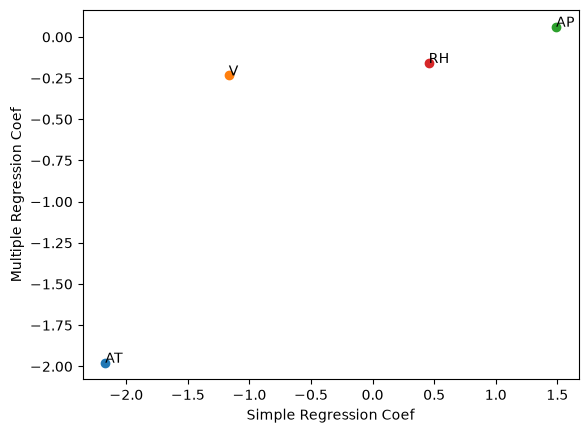

In [12]:
simple_Coefficients = {}
multiple_Coefficients = {}

for p in my_predictors:
    simpleX = sm.add_constant(my_dataframe[p])
    my_simple_model = sm.OLS(y,simpleX).fit()
    simple_Coefficients[p] = my_simple_model.params[p]

#multi regression coef
multiX = sm.add_constant(my_dataframe[my_predictors])
new_multi_model = sm.OLS(y,multiX).fit()
for p in my_predictors:
    multiple_Coefficients[p] = new_multi_model.params[p]


#Plotting the comparison
for p in my_predictors:
    X_val = simple_Coefficients[p]
    y_val = multiple_Coefficients[p]
    plt.scatter(X_val,y_val)
    plt.annotate(p,(X_val,y_val))

#Setting up the labels
plt.xlabel('Simple Regression Coef')
plt.ylabel('Multiple Regression Coef')

plt.show()

### (f) Nonlinear Association

In [17]:
#Implementing a model using the equation given the the HW pdf
for p in my_predictors:
    df_copy = my_dataframe[[p]].copy()
    df_copy[f'{p}^2'] = df_copy[p] ** 2
    df_copy[f'{p}^3'] = df_copy[p] ** 3
    df_copy = sm.add_constant(df_copy)

    equation_model = sm.OLS(y,df_copy).fit()

    print("The Predictor is:",p)
    print(equation_model.summary())
    print()

The Predictor is: AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:04:46   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.67

C:\Users\ashka\AppData\Local\Temp\ipykernel_27452\4211117466.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  equation_model = sm.OLS(y,df_copy).fit()


### (g) Interactions of Predictors

In [21]:
from itertools import combinations

anotherDF_copy = my_dataframe[my_predictors].copy()

#Creating combinations of predictors
for point1,point2 in combinations(my_predictors,2):
    anotherDF_copy[f'{point1}_x_{point2}'] = anotherDF_copy[point1] * anotherDF_copy[point2]

anotherDF_copy = sm.add_constant(anotherDF_copy)

#Creating a full linear regression model
full_linear_model = sm.OLS(y,anotherDF_copy).fit()

#Printing the statistical results of the model after being trained
print(full_linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:15:42   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

### (h) Improvement

In [24]:
#Creating a new dataframe using 70% of all predictors data

selected_df = my_dataframe[my_predictors].sample(frac = 0.7,random_state = 42)
new_y = my_dataframe[my_target].sample(frac = 0.7,random_state = 42)

#Running the regression model using the randomly selected data of predictors
selected_df = sm.add_constant(selected_df)
regression_model = sm.OLS(new_y,selected_df).fit()

print(regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:42:13   Log-Likelihood:                -19657.
No. Observations:                6698   AIC:                         3.932e+04
Df Residuals:                    6693   BIC:                         3.936e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        449.6961     11.636     38.647      0.0

In [ ]:
#Creating a regression model with interaction terms and quadric nonlinearities

### (i) KNN

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

X = my_dataframe[my_predictors]
y = my_dataframe[my_target]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)
scaler = StandardScaler()

X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

k_vals = list(range(1,101,1))
training_MSE = []
testing_MSE = []



In [29]:
for k in k_vals:
    KNN = KNeighborsRegressor(n_neighbors = k)
    KNN.fit(X_train_Scaled,y_train)

    training_prediction = KNN.predict(X_train_Scaled)
    testing_prediction = KNN.predict(X_test_Scaled)

    training_MSE.append(mean_squared_error(y_train,training_prediction))
    testing_MSE.append(mean_squared_error(y_test,testing_prediction))

#Finding the Best K value
k_best = k_vals[testing_MSE.index(min(testing_MSE))]
best_testing_MSE = min(testing_MSE)

#Printing the results
print("The best K-Value:", k_best)
print("The best testing MSE:",best_testing_MSE)

The best K-Value: 4
The best testing MSE: 14.305669422675024


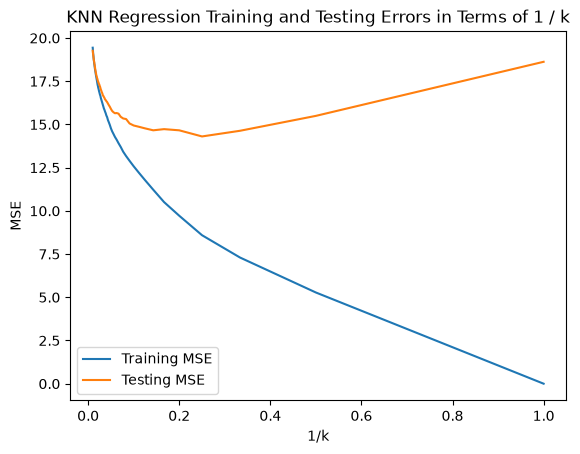

In [37]:
#plotting training and testing errors in terms of 1/k
inverse_k = []

for k in k_vals:
    inverse_k.append(1/k)

plt.plot(inverse_k,training_MSE, label = 'Training MSE')
plt.plot(inverse_k,testing_MSE, label = 'Testing MSE')

plt.title('KNN Regression Training and Testing Errors in Terms of 1 / k')
plt.xlabel('1/k')
plt.ylabel('MSE')

plt.legend()
plt.show()

### (j ) Compare KNN and Linear

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible model will be better suited to be used based on these parameters. Because of a high n and low p, a flexible model can be trained and learn the true relationship between predictors and a target without overfitting the data. 

### (b) The number of predictors p is extremely large, and the number of observations n is small.

The better method to implement based on these parameters would be an inflexible model or method. This appraoch is the best way of solving problems because a flexible method would overfit the data because of the low number of observations and high number of predictors. It follows the idea of the curse of dimensionality, so a flexible model would not work.

### (c) The relationship between the predictors and response is highly non-linear.

The better method or model to use here would be better for these parameters because an inflexible model or method would not be able to train or learn the shape of the data and has a high bias, whereas since a flexible model has a lot more freedoms, has less bias, and it would be able to find the shape of the data. 

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

The better method or model to implement based on these parameter would be an inflexible model. A flexible model has too much freedom, which allows it to overfit the training data.  An inflexible model or method is to strict or has a lot of limitations which allows it to be trained and learn the shape of the data based on this parameter.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [10]:
import numpy as np
from collections import Counter

my_arry = np.array([
    [0,3,0],
    [2,0,0],
    [0,1,3],
    [0,1,2],
    [-1,0,1],
    [1,1,1]])

categorical_arry = np.array(["Red","Red","Red","Green","Green","Red"])

req_arry = np.array([0,0,0])

euclidean_distance = np.sqrt(((my_arry - req_arry) ** 2).sum(axis=1))

for i in range(len(euclidean_distance)):
    d = euclidean_distance[i]
    label = categorical_arry[i]

    print(f"Obs {i + 1}: distance = {d:.2f}: y = {label}")
    

Obs 1: distance = 3.00: y = Red
Obs 2: distance = 2.00: y = Red
Obs 3: distance = 3.16: y = Red
Obs 4: distance = 2.24: y = Green
Obs 5: distance = 1.41: y = Green
Obs 6: distance = 1.73: y = Red


### (b) What is our prediction with K = 1? Why?

In [11]:
k = 1
def knn_prediction():
    K_closest = np.argsort(euclidean_distance)[:k]
    prediction = Counter(categorical_arry[K_closest])

    return prediction.most_common(1)[0][0]


print("K = ", k)
print("Prediction = ", knn_prediction())

K =  1
Prediction =  Green


### (c) What is our prediction with K = 3? Why?

In [12]:
k = 3
def knn_prediction():
    K_closest = np.argsort(euclidean_distance)[:k]
    prediction = Counter(categorical_arry[K_closest])

    return prediction.most_common(1)[0][0]


print("K = ", k)
print("Prediction = ", knn_prediction())

K =  3
Prediction =  Red


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

The best value for K based on a highly non-linear bayes decision boundary is a small K. A small K is best for this situation because  it keeps the bias low enough to then be able to learn the shape of the data more accurate.